In [2]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("football_data.csv")

# Dictionary for mapping
maps = {
    "Weather": {
        "Sunny": 0,
        "Cloudy": 1,
        "Rain": 2
    },
    "Temperature": {
        "Cool": 0,
        "Mild": 1,
        "Hot": 2
    },
    "Humidity": {
        "Normal": 0,
        "High": 1
    },
    "Wind": {
        "Weak": 0,
        "Strong": 1
    },
    "PlayFootball": {
        "No": 0,
        "Yes": 1
    }
}

# Convert text to numbers using loop
for key, value in maps.items():
    df[key] = df[key].map(value)

features = [
    "Weather",
    "Temperature",
    "Humidity",
    "Wind"
]

X = df[features].values
y = df["PlayFootball"]

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X, y)

def PlayFootball(weather, temperature, humidity, wind):

    values = [
        maps["Weather"][weather],
        maps["Temperature"][temperature],
        maps["Humidity"][humidity],
        maps["Wind"][wind]
    ]

    pred = model.predict([values])

    if pred[0] == 1:
        print("Yes, you can play football.")
    else:
        print("No, you should not play football.")

# Run
PlayFootball("Sunny", "Hot", "High", "Weak")

No, you should not play football.


In [3]:
accuracy = model.score(X, y)

print("Random Forest")
print("Accuracy:", accuracy)
print("----------------------")

Random Forest
Accuracy: 1.0
----------------------


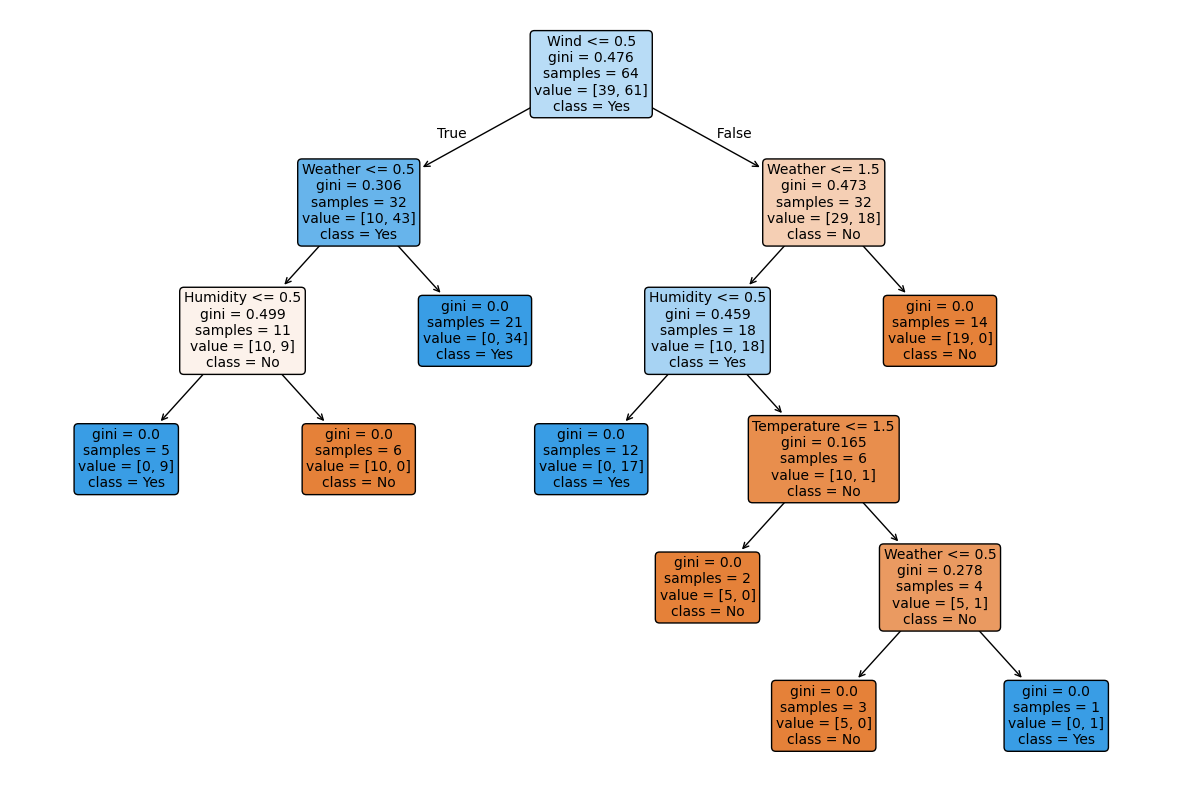

In [4]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

plot_tree(
    model.estimators_[0],
    feature_names=features,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()

In [ ]:
/